In [ ]:
import pandas as pd

data = {
    "Gender": [
        "Male", "Female", "Male", "Female", "Male",
        "Female", "Male", "Female", "Male", "Female",
        "Male", "Female", "Male", "Female", "Male",
        "Female", "Male", "Female", "Male", "Female"
    ],

    "StudyHours": [
        5, 3, 7, 2, 6,
        4, 2, 8, 3, 6,
        7, 2, 4, 7, 8,
        3, 5, 5, 2, 8
    ],

    "Attendance": [
        85, 70, 90, 60, 88,
        75, 55, 95, 65, 85,
        92, 50, 72, 90, 96,
        68, 80, 82, 58, 94
    ],

    "Assignments": [
        80, 65, 95, 55, 85,
        70, 50, 90, 60, 80,
        88, 45, 68, 85, 92,
        60, 75, 78, 52, 91
    ],

    "Pass": [
        1, 0, 1, 0, 1,
        1, 0, 1, 0, 1,
        1, 0, 0, 1, 1,
        0, 1, 1, 0, 1
    ]
}

df = pd.DataFrame(data)

# Save as CSV
df.to_csv("student_data.csv", index=False)

print("student_data.csv created successfully!")
print()
print(df)

student_data.csv created successfully!

    Gender  StudyHours  Attendance  Assignments  Pass
0     Male           5          85           80     1
1   Female           3          70           65     0
2     Male           7          90           95     1
3   Female           2          60           55     0
4     Male           6          88           85     1
5   Female           4          75           70     1
6     Male           2          55           50     0
7   Female           8          95           90     1
8     Male           3          65           60     0
9   Female           6          85           80     1
10    Male           7          92           88     1
11  Female           2          50           45     0
12    Male           4          72           68     0
13  Female           7          90           85     1
14    Male           8          96           92     1
15  Female           3          68           60     0
16    Male           5          80        

In [ ]:
import os

print(os.listdir())

['.config', 'student_data.csv.txt', 'student_data.csv', 'sample_data']


In [ ]:
df = pd.read_csv("student_data.csv")

In [ ]:
# Load the dataset
import pandas as pd

df = pd.read_csv("student_data.csv")

print("Dataset loaded successfully!")
print()
print(df)

Dataset loaded successfully!

    Gender  StudyHours  Attendance  Assignments  Pass
0     Male           5          85           80     1
1   Female           3          70           65     0
2     Male           7          90           95     1
3   Female           2          60           55     0
4     Male           6          88           85     1
5   Female           4          75           70     1
6     Male           2          55           50     0
7   Female           8          95           90     1
8     Male           3          65           60     0
9   Female           6          85           80     1
10    Male           7          92           88     1
11  Female           2          50           45     0
12    Male           4          72           68     0
13  Female           7          90           85     1
14    Male           8          96           92     1
15  Female           3          68           60     0
16    Male           5          80           75     

In [ ]:
# Check the columns
print("Columns:")
print(df.columns.tolist())

print("\nDataset shape:")
print(df.shape)

Columns:
['Gender', 'StudyHours', 'Attendance', 'Assignments', 'Pass']

Dataset shape:
(20, 5)


In [ ]:
# ============================================================
# RANDOM FOREST STUDENT PASS/FAIL PREDICTION
# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Convert Gender
df["Gender"] = df["Gender"].map({
    "Male": 1,
    "Female": 0
})

# Features
X = df[
    [
        "Gender",
        "StudyHours",
        "Attendance",
        "Assignments"
    ]
]

# Target
y = df["Pass"]

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Create model
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train
model.fit(X_train, y_train)

# Predict
predictions = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(
    y_test,
    predictions
)

print("================================")
print("STUDENT PASS/FAIL PREDICTION")
print("================================")

print("Accuracy:", round(accuracy * 100, 2), "%")

STUDENT PASS/FAIL PREDICTION
Accuracy: 100.0 %



========== FEATURE IMPORTANCE ==========

       Feature  Importance
2   Attendance    0.373102
1   StudyHours    0.317501
3  Assignments    0.306730
0       Gender    0.002667


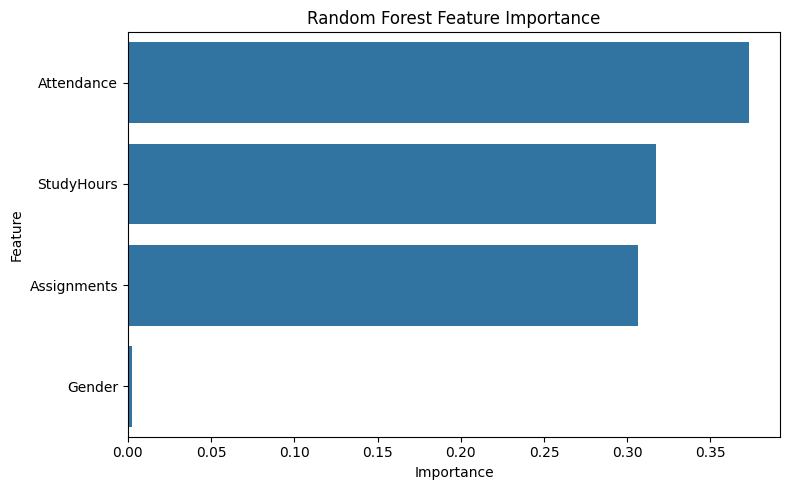

Feature Importance graph saved!


In [ ]:
# ============================================================
# FEATURE IMPORTANCE
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature importance
importance = model.feature_importances_

# Create DataFrame
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
})

# Sort by importance
importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

print("\n========== FEATURE IMPORTANCE ==========\n")
print(importance_df)

# Plot
plt.figure(figsize=(8, 5))

sns.barplot(
    data=importance_df,
    x="Importance",
    y="Feature"
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()

plt.savefig(
    "feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Feature Importance graph saved!")

In [ ]:
!pip install shap -q

Generating SHAP explanation...


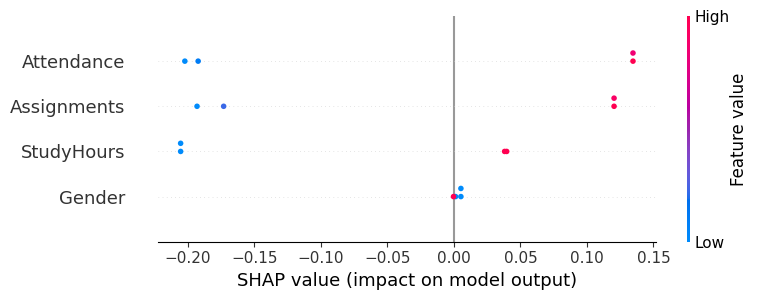

SHAP plot saved successfully!


In [ ]:
# ============================================================
# SHAP EXPLAINABILITY
# ============================================================

import shap
import matplotlib.pyplot as plt

print("Generating SHAP explanation...")

# Create SHAP explainer
explainer = shap.TreeExplainer(model)

# Calculate SHAP values
shap_values = explainer.shap_values(X_test)

# Handle different SHAP versions
if isinstance(shap_values, list):
    shap_plot_values = shap_values[1]
else:
    shap_plot_values = shap_values

    # Some newer SHAP versions return:
    # samples × features × classes
    if len(shap_plot_values.shape) == 3:
        shap_plot_values = shap_plot_values[:, :, 1]

# Create SHAP summary plot
plt.figure(figsize=(8, 6))

shap.summary_plot(
    shap_plot_values,
    X_test,
    show=False
)

plt.tight_layout()

plt.savefig(
    "shap_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("SHAP plot saved successfully!")

In [ ]:
# ============================================================
# BIAS ANALYSIS
# ============================================================

print("\n========== BIAS ANALYSIS ==========\n")

# Male students
male_students = df[df["Gender"] == 1]

# Female students
female_students = df[df["Gender"] == 0]

# Calculate actual pass rates
male_pass_rate = male_students["Pass"].mean() * 100
female_pass_rate = female_students["Pass"].mean() * 100

print(
    "Male Student Pass Rate:",
    round(male_pass_rate, 2),
    "%"
)

print(
    "Female Student Pass Rate:",
    round(female_pass_rate, 2),
    "%"
)

# Difference in pass rates
difference = abs(
    male_pass_rate - female_pass_rate
)

print(
    "Pass Rate Difference:",
    round(difference, 2),
    "%"
)

# Simple interpretation
if difference < 10:
    print("\nBias Difference: Low")
elif difference < 20:
    print("\nBias Difference: Moderate")
else:
    print("\nBias Difference: High")


========== BIAS ANALYSIS ==========

Male Student Pass Rate: 60.0 %
Female Student Pass Rate: 60.0 %
Pass Rate Difference: 0.0 %

Bias Difference: Low


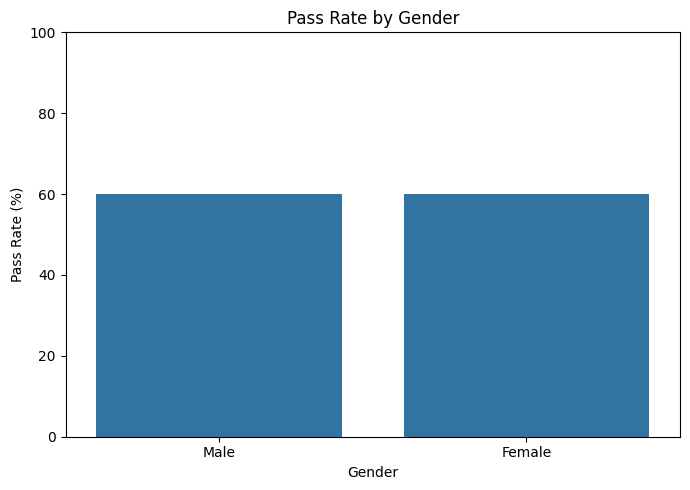

Bias analysis graph saved!


In [ ]:
# ============================================================
# BIAS ANALYSIS GRAPH
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns

gender_pass_rates = pd.DataFrame({
    "Gender": ["Male", "Female"],
    "Pass Rate": [
        male_pass_rate,
        female_pass_rate
    ]
})

plt.figure(figsize=(7, 5))

sns.barplot(
    data=gender_pass_rates,
    x="Gender",
    y="Pass Rate"
)

plt.title("Pass Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Pass Rate (%)")

plt.ylim(0, 100)

plt.tight_layout()

plt.savefig(
    "bias_analysis.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Bias analysis graph saved!")

In [ ]:
# ============================================================
# STUDENT PASS/FAIL PREDICTION
# ============================================================

print("\n========== STUDENT PREDICTION ==========\n")

# Get Gender
while True:
    gender_input = input(
        "Enter Gender (Male/Female): "
    ).strip().lower()

    if gender_input in ["male", "female"]:
        break

    print("Please enter Male or Female.")


# Get Study Hours
while True:
    try:
        study_hours = float(
            input("Enter Study Hours: ")
        )

        if study_hours < 0:
            print("Study hours cannot be negative.")
        else:
            break

    except ValueError:
        print("Please enter a valid number.")


# Get Attendance
while True:
    try:
        attendance = float(
            input("Enter Attendance (%): ")
        )

        if attendance < 0 or attendance > 100:
            print("Attendance must be between 0 and 100.")
        else:
            break

    except ValueError:
        print("Please enter a valid number.")


# Get Assignment Marks
while True:
    try:
        assignments = float(
            input("Enter Assignment Marks: ")
        )

        if assignments < 0 or assignments > 100:
            print("Assignment marks must be between 0 and 100.")
        else:
            break

    except ValueError:
        print("Please enter a valid number.")


# Convert Gender
if gender_input == "male":
    gender = 1
else:
    gender = 0


# Create student data
new_student = pd.DataFrame({
    "Gender": [gender],
    "StudyHours": [study_hours],
    "Attendance": [attendance],
    "Assignments": [assignments]
})


# Make prediction
prediction = model.predict(new_student)

probability = model.predict_proba(new_student)


# Display result
print("\n========== FINAL RESULT ==========\n")

if prediction[0] == 1:
    print("FINAL RESULT: PASS")
else:
    print("FINAL RESULT: FAIL")


print(
    "Pass Probability:",
    round(probability[0][1] * 100, 2),
    "%"
)

print(
    "Fail Probability:",
    round(probability[0][0] * 100, 2),
    "%"
)


========== STUDENT PREDICTION ==========

Enter Gender (Male/Female): male
Enter Study Hours: 5
Enter Attendance (%): 79
Enter Assignment Marks: 57

========== FINAL RESULT ==========

FINAL RESULT: PASS
Pass Probability: 61.0 %
Fail Probability: 39.0 %
